---
title: "Lecture 16: Basic methods for IVPs"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture16_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Initial-value problems

::: {.callout-note icon=false}
## Definition: Initial-value problem (scalar)
A scalar first-order **initial-value problem** (IVP) is

\begin{align*}
    &u'(t) = f(t,u(t)), & a \le t \le b \\
    &u(a) = u_0. & 
\end{align*}

We call $t$ the **independent variable** and $u$ the **dependent variable**.  If $u' = f(t,u) = g(t) + uh(t)$, the differential equation is **linear**; otherwise, it is **nonlinear**.

A **solution** of an initial-value problem is a function $u(t)$ that makes both $u'(t) = f(t,u(t))$ and $u(a) = u_0$ true equations.
:::

## Basics of IVPs

Linear IVPs can be solved in terms of integrals using an *integrating factor*.  However, often the necessary integrals cannot be computed in closed form. 

. . .
 
Nonlinear IVPs are typically even more challenging.  

. . .

Most often, there is no analytic formula available for the solution of an IVP. 

## Numerical solutions

Numerical techniques for IVPs do not use techniques you may have learned in Differential Equations to produce analytic formulas for the solution.  Instead, they approximate power series, integrals, and derivatives locally and use iterative progression to advance the independent variable and approximate a solution.

. . .

While numerical techniques are approximative, they are far more robust than analytic techniques in the scope of problems they can solve.  

In [27]:
# | echo: false
#using Pkg; Pkg.add("DifferentialEquations")
using DifferentialEquations
using Plots
using LinearAlgebra

In [10]:
f = (u,p,t) -> sin((t+u)^2)   # defines du/dt, must include p -- not used here
u₀ = -1.0                     # initial value
tspan = (0.0,4.0)             # t interval

(0.0, 4.0)

In [11]:
ivp = ODEProblem(f,u₀,tspan)
sol = solve(ivp,Tsit5());

---

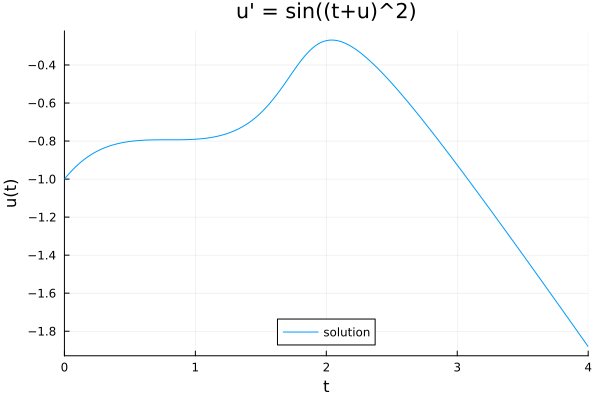

In [12]:
plot(sol,label="solution",legend=:bottom,xlabel="t",ylabel="u(t)",title="u' = sin((t+u)^2)")

---

In [15]:
@show sol(1.0);   # sol acts like a function
[sol.t sol.u]     # under the hood, sol is defined by u values 
                  # at t nodes and is interpolated

sol(1.0) = -0.7903205813665345


15×2 Matrix{Float64}:
 0.0        -1.0
 0.0867807  -0.93483
 0.241035   -0.856617
 0.464665   -0.805668
 0.696832   -0.793614
 1.00862    -0.789925
 1.37461    -0.718601
 1.70407    -0.476837
 1.93572    -0.29033
 2.17184    -0.294994
 2.4843     -0.483948
 2.69425    -0.654121
 3.27049    -1.1783
 3.62534    -1.51729
 4.0        -1.88086

---

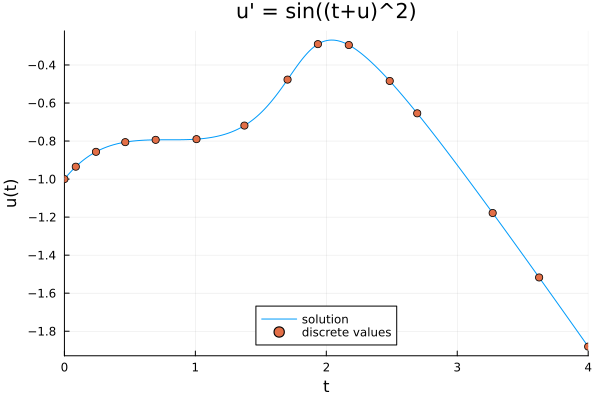

In [16]:
scatter!(sol.t,sol.u,label="discrete values")

## Existence

There are some simple IVPs that do not have solutions at all possible times.

In [17]:
f = (u,p,t) -> (t+u)^2
ivp = ODEProblem(f,1.0,(0.,1.))
sol = solve(ivp,Tsit5());

┌ Warning: At t=0.7853839417697203, dt was forced below floating point epsilon 1.1102230246251565e-16, and step error estimate = 42.16290621054672. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase ~/.julia/packages/SciMLBase/XzPx0/src/integrator_interface.jl:623


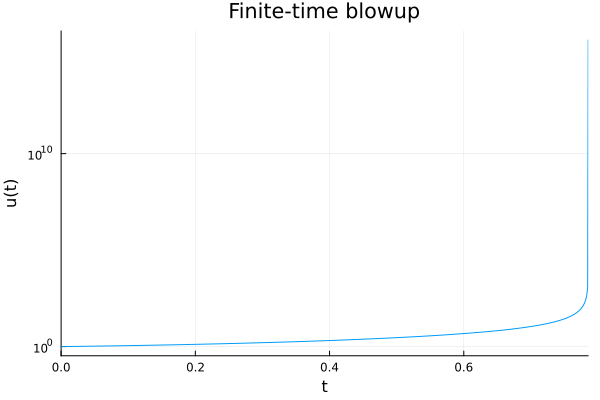

In [18]:
plot(sol,label="",xlabel="t",yaxis=(:log10,"u(t)"),title="Finite-time blowup")

## Uniqueness

IVPs may also have more than one solution.

. . .

[However, there is a condition we can check that guarantees that a unique solution exists.]{.content-hidden when-format='revealjs' when-format='pptx'} 

::: {.callout-warning icon=false}
## Theorem: Existence and uniqueness
If the derivative $\frac{\partial f}{\partial u}$ exists and $\left|\frac{\partial f}{\partial u}\right|$ is bounded by a constant $L$ for all $a \le t \le b$ and all $u$, then the initial-value problem defined by $f$ has a unique solution for $t \in [a,b]$.
:::

## Conditioning of first-order IVPs

We'll focus on the effect of perturbations to $u_0$ and not to $f(t,u)$.  

. . .

::: {.callout-warning icon=false}
## Theorem: Dependence on initial value
If the derivative $\frac{\partial f}{\partial u}$ exists and $\left|\frac{\partial f}{\partial u}\right|$ is bounded by a constant $L$ for all $a \le t \le b$ and all $u$, then the solution $u(t;u_0 + \delta)$ of $u' = f(t,u)$ with initial condition $u(0) = u_0 + \delta$ satisfies $$\|u(t;u_0+\delta) - u(t;u_0)\|_\infty \le |\delta| e^{L(b-a)}$$ for all sufficiently small $|\delta|$.
:::

. . .

This theorem gives $e^{L(b-a)}$ as an upper bound on the infinity norm absolute condition number of the solution with respect to perturbations to the IVP initial value.  

. . .

However, like we've seen before, these bounds can be *very* rough.

---

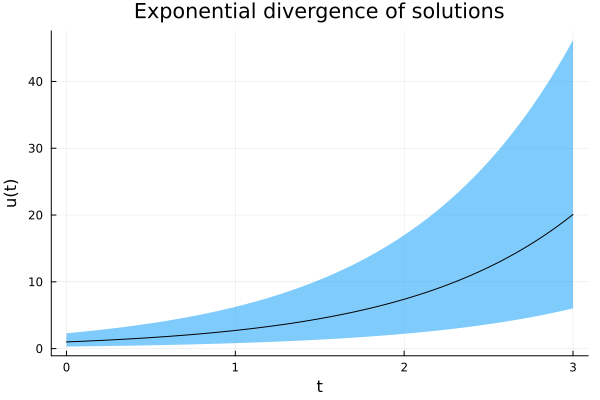

In [19]:
t = range(0,3,length=800)
u = @. exp(t)*1'
lower, upper = @. exp(t)*0.7, @. exp(t)*1.3
plot(t,u,l=:black,ribbon=(lower,upper), leg=:none,xlabel="t",ylabel="u(t)",
    title="Exponential divergence of solutions")

. . .

This IVP has condition number equal to the upper bound provided in the theorem above.

---

But with $u' = -u$, solutions actually get closer over time, so the maximum deviation of the solution is the same as the perturbation to the initial value.



┌ Warning: Skipped line arg bloack.
└ @ Plots ~/.julia/packages/Plots/FFuQi/src/args.jl:1105


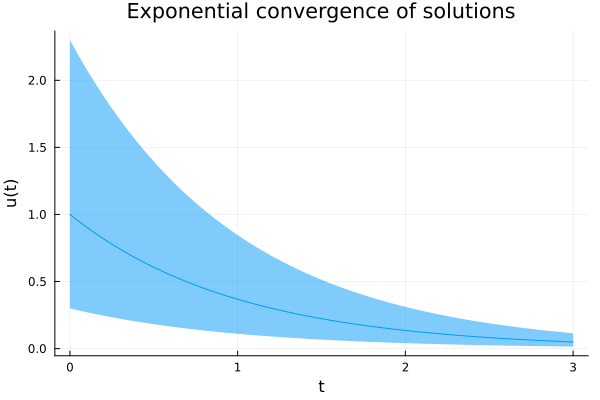

In [20]:
u = @. exp(-t)*1
lower, upper = @. exp(-t)*0.7, @. exp(-t)*1.3
plot(t,u,l=:bloack,ribbon=(lower,upper),leg=:none,xlabel="t",ylabel="u(t)",
    title="Exponential convergence of solutions")

. . .

In this case, the condition number is one.  Here, the exponentially growing bound is a terrible overestimate!

## Euler's Method

One way to estimate a solution to an IVP is to estimate its values at a finite collection of nodes: $$t_i = a + ih, \quad\quad h = \frac{b-a}{n}, \quad\quad i=0, \cdots, n.$$
The number $h$ is called the **step size**.

. . .

We'll let $\hat{u}(t)$ denote the exact solution of the IVP and our approximations at $t_i$ be $u_i \approx \hat{u}(t_i)$.  

. . .

The model that defines Euler's method is asking that the piecewise linear interpolant of the values $u_0, \cdots, u_n$ have slopes equal to the derivatives of the exact solution at the point $(t_i,u_i)$, $$\frac{u_{i+1}-u_i}{h} = \frac{u_{i+1}-u_i}{t_{i+1}-t_i} = f(t_i,u_i).$$

## Algorithm: Euler's method for an IVP

Given the IVP $u' = f(t,u), u(a) = u_0$ and the nodes $t_i = a + ih, h = (b-a)/n$, iteratively compute the sequence $$u_{i+1} = u_i + h f(t_i, u_i), \quad\quad i = 0, \cdots, n-1.$$ 

In [21]:
"""
    euler(ivp,n)

Apply Euler's method to solve the given IVP using 'n' time steps.
Returns a vector of times and a vector of solution values.
"""
function euler(ivp,n)
        # Time discretization
        a,b = ivp.tspan
        h = (b-a)/n 
        t = [ a + i*h for i in 0:n ]

        # Initial condition and output setup.
        u = fill(float(ivp.u0),n+1)

        # The time stepping criterion
        for i in 1:n 
            u[i+1] = u[i] + h*ivp.f(u[i],ivp.p,t[i])
        end
        return t,u 
    end

euler

. . .

This is an example of a one-step method.

::: {.callout-note icon=false}
## Definition: One-step IVP method
A **one-step method** is a formula of the form $$u_{i+1} = u_i + h \phi(t_i,u_i,h), \quad\quad i=0,\cdots,n-1.$$
:::

## Error

Suppose we have access to the exact value at $t_i$, $\hat{u}(t_i) = u_i$.  How good is our $u_{i+1}$ approximation to $\hat{u}(t_{i+1})$?  

::: {.callout-caution icon=false}
## Exercise: 
Using Taylor series expansion, simplify $\hat{u}(t_{i+1}) - [u_i + hf(t_i,u_i)]$.
:::
<details><summary>Answer:</summary> 
We have

\begin{align*}
\hat{u}(t_{i+1}) - [u_i + hf(t_i,u_i)] &= \hat{u}(t_{i+1}) - [\hat{u}(t_i) + hf(t_i,\hat{u}(t_i))] \\
&= [\hat{u}(t_i) + h\hat{u}'(t_i) + \frac{h^2}{2}\hat{u}''(t_i) + O(h^3)] - [\hat{u}(t_i) + h\hat{u}'(t_i)] \\
&= \frac{h^2}{2}\hat{u}''(t_i) + O(h^3)
\end{align*}
</details>


## Local truncation error

::: {.callout-note icon=false}
## Definition: Truncation error of a one-step IVP method
The **local truncation error** (LTE) of a one-step method is $$\tau_{i+1}(h) = \frac{\hat{u}(t_{i+1}) - \hat{u}(t_i)}{h} - \phi(t_i,\hat{u}(t_i),h).$$ The method is called **consistent** if $\tau_{i+1}(h) \rightarrow 0$ as $h \rightarrow 0$. 
:::

. . .

Note that the local error in stepping from $t_i$ to $t_{i+1}$ is $h\tau_{i+1}(h)$.  We can make these local errors smaller by chopping $h$ in half, but we would have to take twice as many steps.  The important thing to measure is local error *per unit step length*, which is how $\tau$ is defined.

. . .

::: {.callout-warning icon=false}
## Lemma: 
If $\phi(t,u,0) = f(t,u)$ for any function $u$, then the method defined by $\phi$ is consistent.
:::

## Convergence

::: {.callout-note icon=false}
## Definition: Global error of an IVP solution
Given an IVP whose exact solution is $\hat{u}(t)$, the **global error** of approximate solution values $u_0, u_1, \cdots, u_n$ at times $t_i$ is the vector $[\hat{u}(t_i) - u_i]_{i=0,\cdots,n}$.
:::

. . .

One might hope that the global error simply adds up all of the local errors over the steps taken, however each step causes a perturbation of the solution which then grows.

. . .

::: {.callout-warning icon=false}
## Theorem: 

Suppose that the unit local truncation error of the one step method satisfies $$|\tau_{i+1}(h)| \le C h^p,$$ and that $$\left|\frac{\partial \phi}{\partial u}\right| \le L$$ for all $t \in [a,b]$, all $u$, and all $h > 0$.  Then the global error satisfies $$|\hat{u}(t_i) - u_i| \le \frac{Ch^p}{L} [e^{L(t_i-a)} - 1],$$ which is $O(h^p)$ as $h \rightarrow 0$.  
:::

---

::: {.callout-note icon=false}
## Definition: Order of accuracy of a one-step IVP method
If the local truncation error of the one-step method satisfies $\tau_{i+1}(h) = O(h^p)$ for a positive integer $p$, then $p$ is the **order of accuracy** of the formula.
:::

---

In [22]:
f = (u,p,t) -> sin((t+u)^2);
tspan = (0.0,4.0);
u0 = -1.0;

ivp = ODEProblem(f,u0,tspan)

ODEProblem with uType Float64 and tType Float64. In-place: false
timespan: (0.0, 4.0)
u0: -1.0

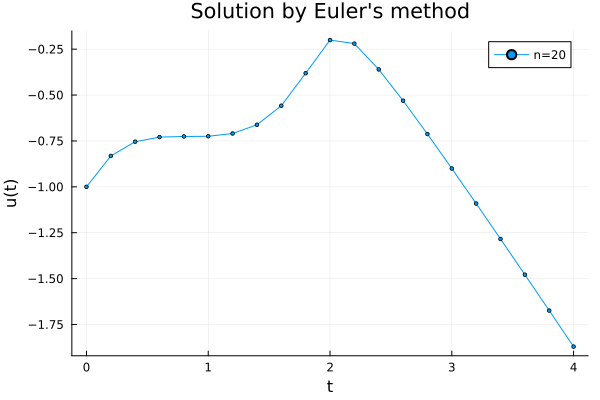

In [23]:
t,u = euler(ivp,20)

plot(t,u,m=2,label="n=20",xlabel="t",ylabel="u(t)",
    title="Solution by Euler's method")

---

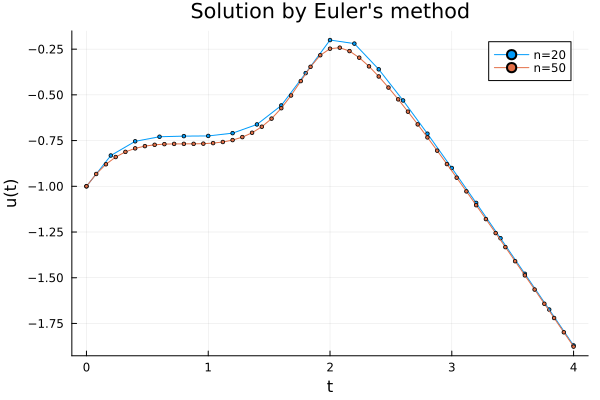

In [24]:
t,u = euler(ivp,50)
plot!(t,u,m=2,label="n=50")

---

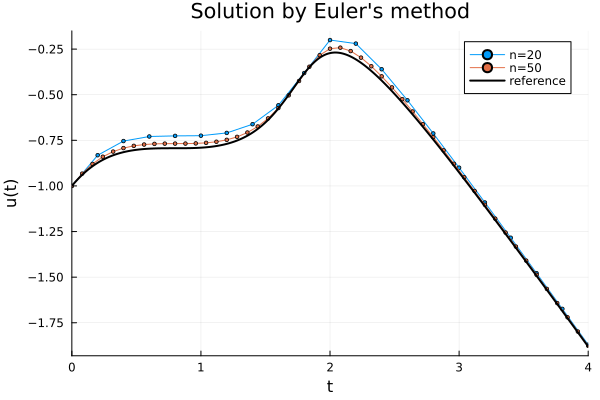

In [25]:
u_exact = solve(ivp,Tsit5(),reltol=1e-14,abstol=1e-14)

plot!(u_exact,l=(2,:black),label="reference")

---

In [28]:
n = [ round(Int,5*10^k) for k in 0:0.5:3 ]
errs = []
for n in n 
    t,u = euler(ivp,n)
    push!(errs, norm(u_exact.(t)-u, Inf) )
end

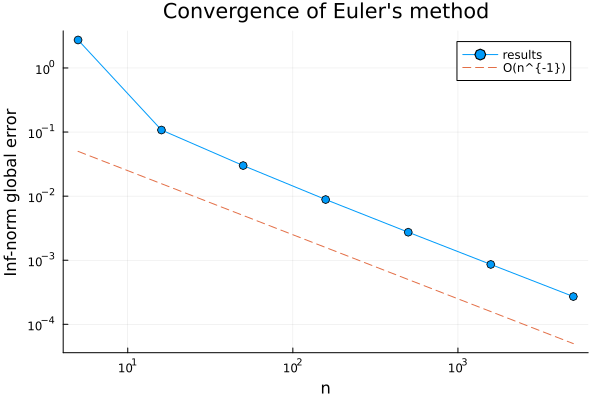

In [30]:
plot(n,errs,m=:o,label="results",xaxis=(:log10,"n"),
    yaxis=(:log10,"Inf-norm global error"),
    title="Convergence of Euler's method")
plot!(n,0.05*(n/n[1]).^(-1),l=:dash,label="O(n^{-1})")

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->